# Airfoil Comparative Aerodynamics — XFLR5 Analysis
**Document:** Airfoil Configuration Analysis  
**Author:** Colin Y. Cooper  
**Tool:** XFLR5 v6.62 — XFoil Direct Analysis (2D)  
**Freestream Speed:** 22 m/s (79.2 km/h)  
**Reynolds Numbers:** 100,000 / 200,000 / 300,000  

---

## Overview

This notebook presents the complete aerodynamic analysis pipeline for airfoil selection for the Modular Wing Comparative Aerodynamics flight test program. This analysis is the **first** of two phases:

**Phase 1 — 2D Airfoil Analysis**  
XFoil polar analysis of three candidate airfoils (MH45, NACA 0009, E214) across the operating Reynolds number range. Used for airfoil selection and pre-test prediction of section aerodynamic coefficients.

**Phase 2 — 3D Wing Configuration Analysis**  
Vortex Lattice Method (VLM2) analysis of three wing configurations at cruise speed. Quantifies induced drag contribution, lift curve characteristics, and pitching moment behavior for each test configuration.

---

## 1. Setup

In [55]:
# Initialize libraries 
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
import numpy as np
import pandas as pd

# Initialize plotting parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'legend.framealpha': 0.9,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# Read airfoil csv data 
mh45_200k     = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\MH45_Re200k.csv')
NACA0009_200k = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\NACA0009_Re200k.csv')
E214_200k     = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\E214_Re200k.csv')

# Insert Lift/Drag ratio into datasets 
mh45_200k['CL/CD'] = mh45_200k['CL']/mh45_200k['CD']
NACA0009_200k['CL/CD'] = NACA0009_200k['CL']/NACA0009_200k['CD']
E214_200k['CL/CD'] = E214_200k['CL']/E214_200k['CD']


## 2. Lift Curve Comparison — All Airfoils at Re 200,000

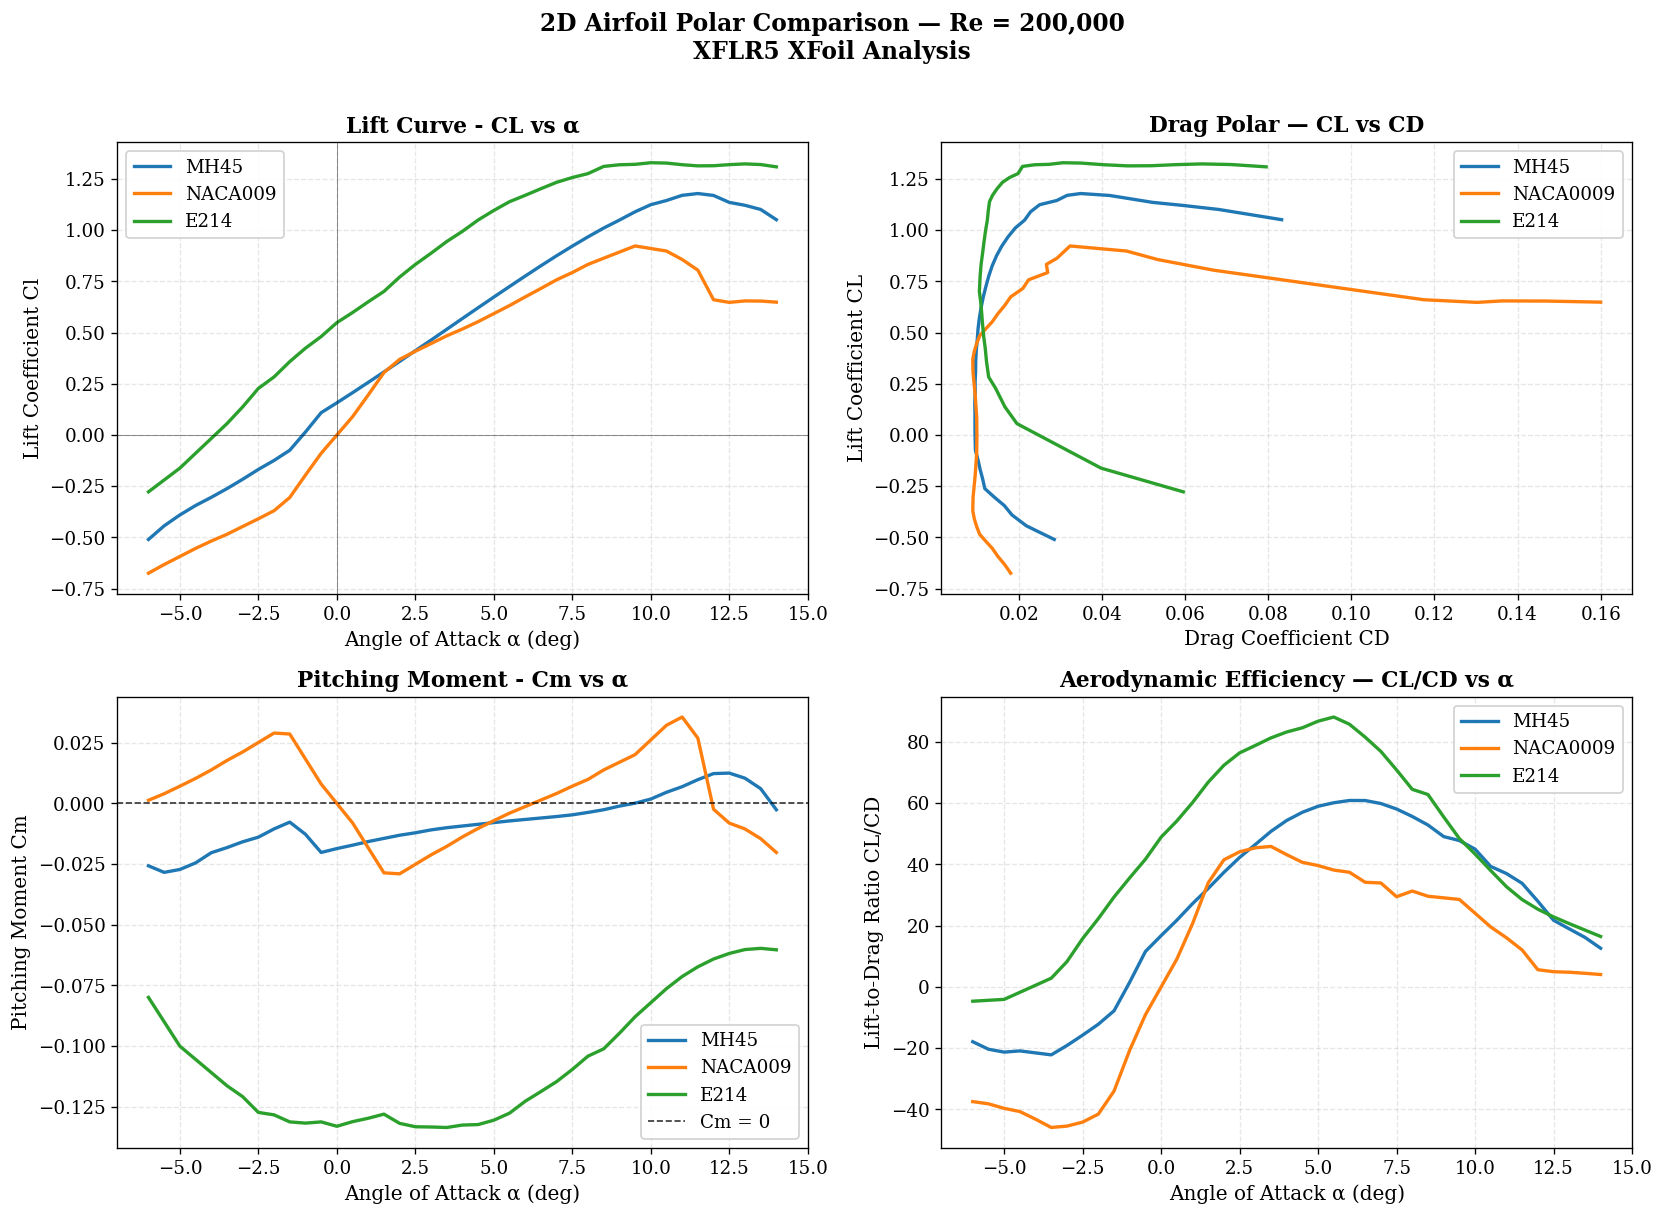

In [56]:
#Define plot size
fig, axes = plt.subplots(2,2, figsize=(14, 10))
fig.suptitle('2D Airfoil Polar Comparison — Re = 200,000\nXFLR5 XFoil Analysis', 
             fontsize=14, fontweight='bold', y=1.01)

ax_cl_a  = axes[0, 0]  # CL vs Alpha
ax_polar = axes[0, 1]  # CL vs CD (drag polar)
ax_cm    = axes[1, 0]  # Cm vs Alpha
ax_ld    = axes[1, 1]  # CL/CD vs alpha

# Lot Lift Curve 
ax_cl_a.plot(mh45_200k['alpha'], mh45_200k['CL'], label = 'MH45')
ax_cl_a.plot(NACA0009_200k['alpha'], NACA0009_200k['CL'], label = 'NACA009')
ax_cl_a.plot(E214_200k['alpha'], E214_200k['CL'], label = 'E214')                      
ax_cl_a.set_xlabel('Angle of Attack α (deg)')
ax_cl_a.set_ylabel('Lift Coefficient Cl')
ax_cl_a.set_title('Lift Curve - CL vs α')
ax_cl_a.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax_cl_a.axvline(0, color='k', linewidth=0.5, alpha=0.5)
ax_cl_a.legend()

# Plot Drag Polar
ax_polar.plot(mh45_200k['CD'], mh45_200k['CL'], label = 'MH45')
ax_polar.plot(NACA0009_200k['CD'],NACA0009_200k['CL'], label = 'NACA0009')
ax_polar.plot(E214_200k['CD'],E214_200k['CL'], label = 'E214')
ax_polar.set_xlabel('Drag Coefficient CD')
ax_polar.set_ylabel('Lift Coefficient CL')
ax_polar.set_title('Drag Polar — CL vs CD')
ax_polar.legend()

# Plot Lift/Drag Ratio 
ax_ld.plot(mh45_200k['alpha'], mh45_200k['CL/CD'], label = 'MH45')
ax_ld.plot(NACA0009_200k['alpha'],NACA0009_200k['CL/CD'], label = 'NACA0009')
ax_ld.plot(E214_200k['alpha'],E214_200k['CL/CD'], label = 'E214')
ax_ld.set_xlabel('Angle of Attack α (deg)')
ax_ld.set_ylabel('Lift-to-Drag Ratio CL/CD')
ax_ld.set_title('Aerodynamic Efficiency — CL/CD vs α')
ax_ld.legend()

# Plot Pitching Moment 
ax_cm.plot(mh45_200k['alpha'], mh45_200k['Cm'], label = 'MH45')
ax_cm.plot(NACA0009_200k['alpha'], NACA0009_200k['Cm'], label = 'NACA009')
ax_cm.plot(E214_200k['alpha'], E214_200k['Cm'], label = 'E214')
ax_cm.axhline(0, color='k', linewidth=1.0, alpha=0.8, linestyle='--', label='Cm = 0')                      
ax_cm.set_xlabel('Angle of Attack α (deg)')
ax_cm.set_ylabel('Pitching Moment Cm')
ax_cm.set_title('Pitching Moment - Cm vs α')
ax_cm.legend()
              


plt.tight_layout()
plt.show()